In [1]:
import os
from pathlib import Path
import matplotlib.pyplot as plt

_TREBL_FIG_DIR = Path.cwd() / 'saved_figures'
_TREBL_FIG_DIR.mkdir(parents=True, exist_ok=True)


def _trebl_notebook_stem():
    session_path = os.environ.get('JPY_SESSION_NAME', '')
    if session_path:
        raw_stem = Path(session_path).stem or 'notebook'
        safe_stem = ''.join(ch if (ch.isalnum() or ch in {'_', '-'}) else '_' for ch in raw_stem)
        return safe_stem.strip('_') or 'notebook'
    return 'notebook'


# Reset counter and stem every time this cell runs so re-running replaces existing images
if hasattr(plt, '_trebl_autosave_original_show'):
    plt.show = plt._trebl_autosave_original_show

plt._trebl_autosave_original_show = plt.show
plt._trebl_autosave_counter = 1
plt._trebl_notebook_stem = _trebl_notebook_stem()


def _trebl_autosave_show(*args, **kwargs):
    for fig_num in plt.get_fignums():
        fig = plt.figure(fig_num)
        stem = f"{plt._trebl_notebook_stem}_figure_{plt._trebl_autosave_counter:04d}"
        fig.savefig(_TREBL_FIG_DIR / f'{stem}.png', dpi=300, bbox_inches='tight')
        fig.savefig(_TREBL_FIG_DIR / f'{stem}.pdf', dpi=300, bbox_inches='tight')
        plt._trebl_autosave_counter += 1
    return plt._trebl_autosave_original_show(*args, **kwargs)


plt.show = _trebl_autosave_show


In [29]:
import pandas as pd 
import glob
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [24]:
reads_per_umi_paths = glob.glob("../../../output/ChopTFs_pipeline/trebl_experiment_/trebl_experiment_*/*_reads_per_umi.tsv")
reads_per_umi_paths_df = pd.DataFrame(reads_per_umi_paths)
reads_per_umi_paths_df["seq_type"] = reads_per_umi_paths_df[0].str.extract("_fastp/(..)_\d")
reads_per_umi_paths_df["rep"] = reads_per_umi_paths_df[0].str.extract("_fastp/.*_(\d+)_\d+").astype(int)
reads_per_umi_paths_df["time"] = reads_per_umi_paths_df[0].str.extract("_fastp/.*_\d+_(\d+)").astype(int)
reads_per_umi_paths_df = reads_per_umi_paths_df.sort_values(by = ["seq_type", "rep", "time"])
reads_per_umi_paths_df = reads_per_umi_paths_df.reset_index(drop = True)
reads_per_umi_paths_df = reads_per_umi_paths_df.rename(columns = {0: "path"})
reads_per_umi_paths_df.head()

,path,seq_type,rep,time
0,../../../output/ChopTFs_pipeline/trebl_experim...,AD,2,0
1,../../../output/ChopTFs_pipeline/trebl_experim...,AD,2,2
2,../../../output/ChopTFs_pipeline/trebl_experim...,AD,2,5
3,../../../output/ChopTFs_pipeline/trebl_experim...,AD,2,10
4,../../../output/ChopTFs_pipeline/trebl_experim...,AD,2,15


../../../output/ChopTFs_pipeline/trebl_experiment_/trebl_experiment_AD_2_0_S1_R1_001_fastp/AD_2_0_S1_R1_001_fastp_reads_per_umi.tsv
../../../output/ChopTFs_pipeline/trebl_experiment_/trebl_experiment_AD_2_2_S2_R1_001_fastp/AD_2_2_S2_R1_001_fastp_reads_per_umi.tsv
../../../output/ChopTFs_pipeline/trebl_experiment_/trebl_experiment_AD_2_5_S3_R1_001_fastp/AD_2_5_S3_R1_001_fastp_reads_per_umi.tsv
../../../output/ChopTFs_pipeline/trebl_experiment_/trebl_experiment_AD_2_10_S4_R1_001_fastp/AD_2_10_S4_R1_001_fastp_reads_per_umi.tsv
../../../output/ChopTFs_pipeline/trebl_experiment_/trebl_experiment_AD_2_15_S5_R1_001_fastp/AD_2_15_S5_R1_001_fastp_reads_per_umi.tsv
../../../output/ChopTFs_pipeline/trebl_experiment_/trebl_experiment_AD_2_20_S6_R1_001_fastp/AD_2_20_S6_R1_001_fastp_reads_per_umi.tsv
../../../output/ChopTFs_pipeline/trebl_experiment_/trebl_experiment_AD_2_30_S7_R1_001_fastp/AD_2_30_S7_R1_001_fastp_reads_per_umi.tsv
../../../output/ChopTFs_pipeline/trebl_experiment_/trebl_experiment_

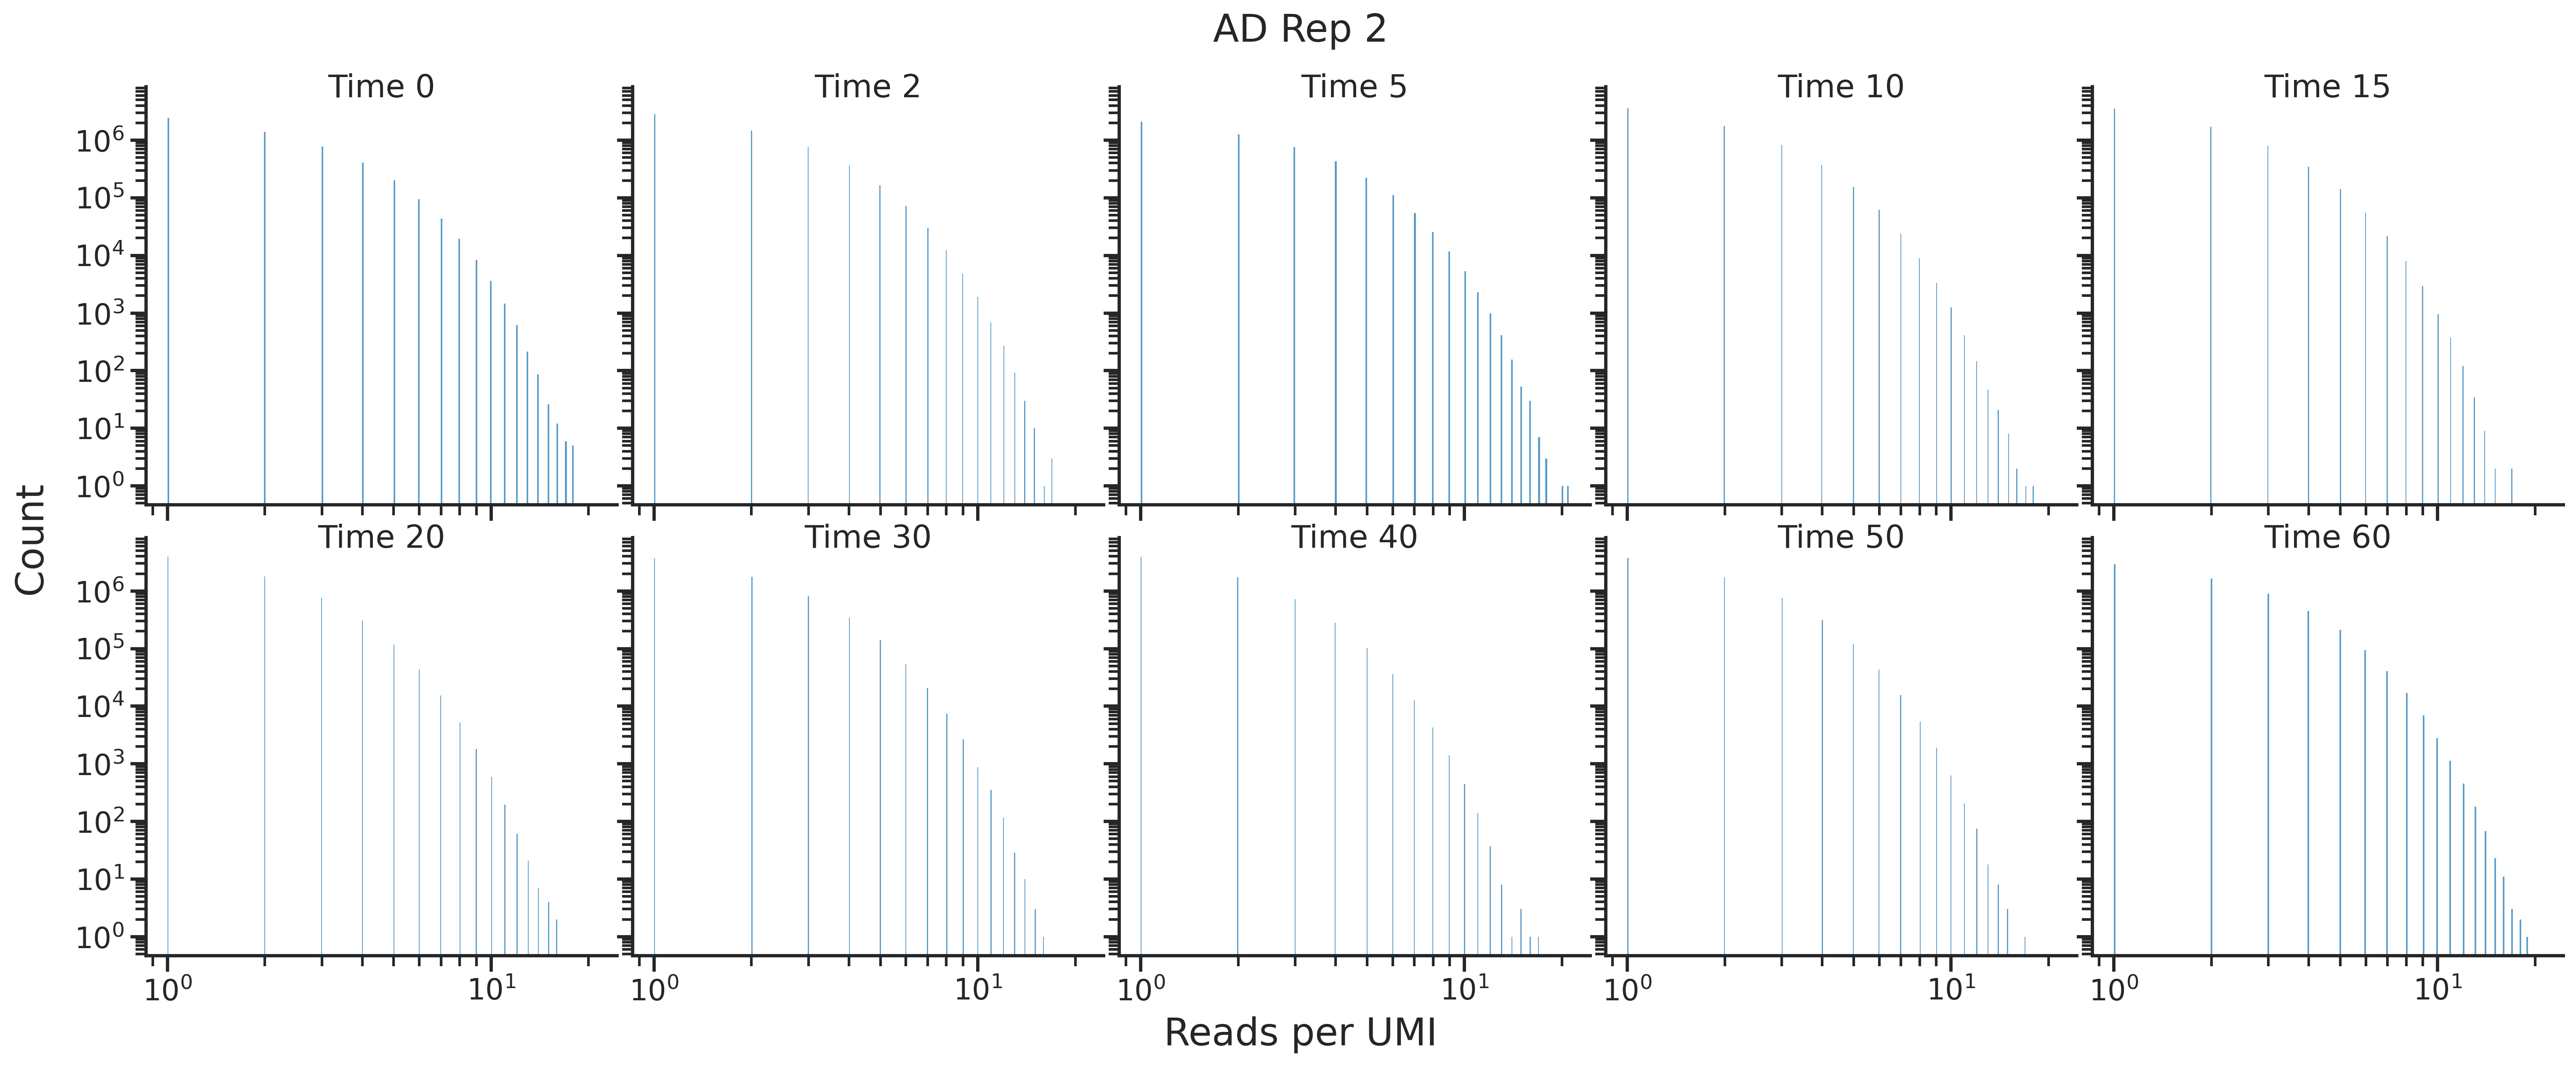

../../../output/ChopTFs_pipeline/trebl_experiment_/trebl_experiment_AD_3_0_S11_R1_001_fastp/AD_3_0_S11_R1_001_fastp_reads_per_umi.tsv
../../../output/ChopTFs_pipeline/trebl_experiment_/trebl_experiment_AD_3_2_S12_R1_001_fastp/AD_3_2_S12_R1_001_fastp_reads_per_umi.tsv
../../../output/ChopTFs_pipeline/trebl_experiment_/trebl_experiment_AD_3_5_S13_R1_001_fastp/AD_3_5_S13_R1_001_fastp_reads_per_umi.tsv
../../../output/ChopTFs_pipeline/trebl_experiment_/trebl_experiment_AD_3_10_S14_R1_001_fastp/AD_3_10_S14_R1_001_fastp_reads_per_umi.tsv
../../../output/ChopTFs_pipeline/trebl_experiment_/trebl_experiment_AD_3_15_S15_R1_001_fastp/AD_3_15_S15_R1_001_fastp_reads_per_umi.tsv
../../../output/ChopTFs_pipeline/trebl_experiment_/trebl_experiment_AD_3_20_S16_R1_001_fastp/AD_3_20_S16_R1_001_fastp_reads_per_umi.tsv
../../../output/ChopTFs_pipeline/trebl_experiment_/trebl_experiment_AD_3_30_S17_R1_001_fastp/AD_3_30_S17_R1_001_fastp_reads_per_umi.tsv
../../../output/ChopTFs_pipeline/trebl_experiment_/tre

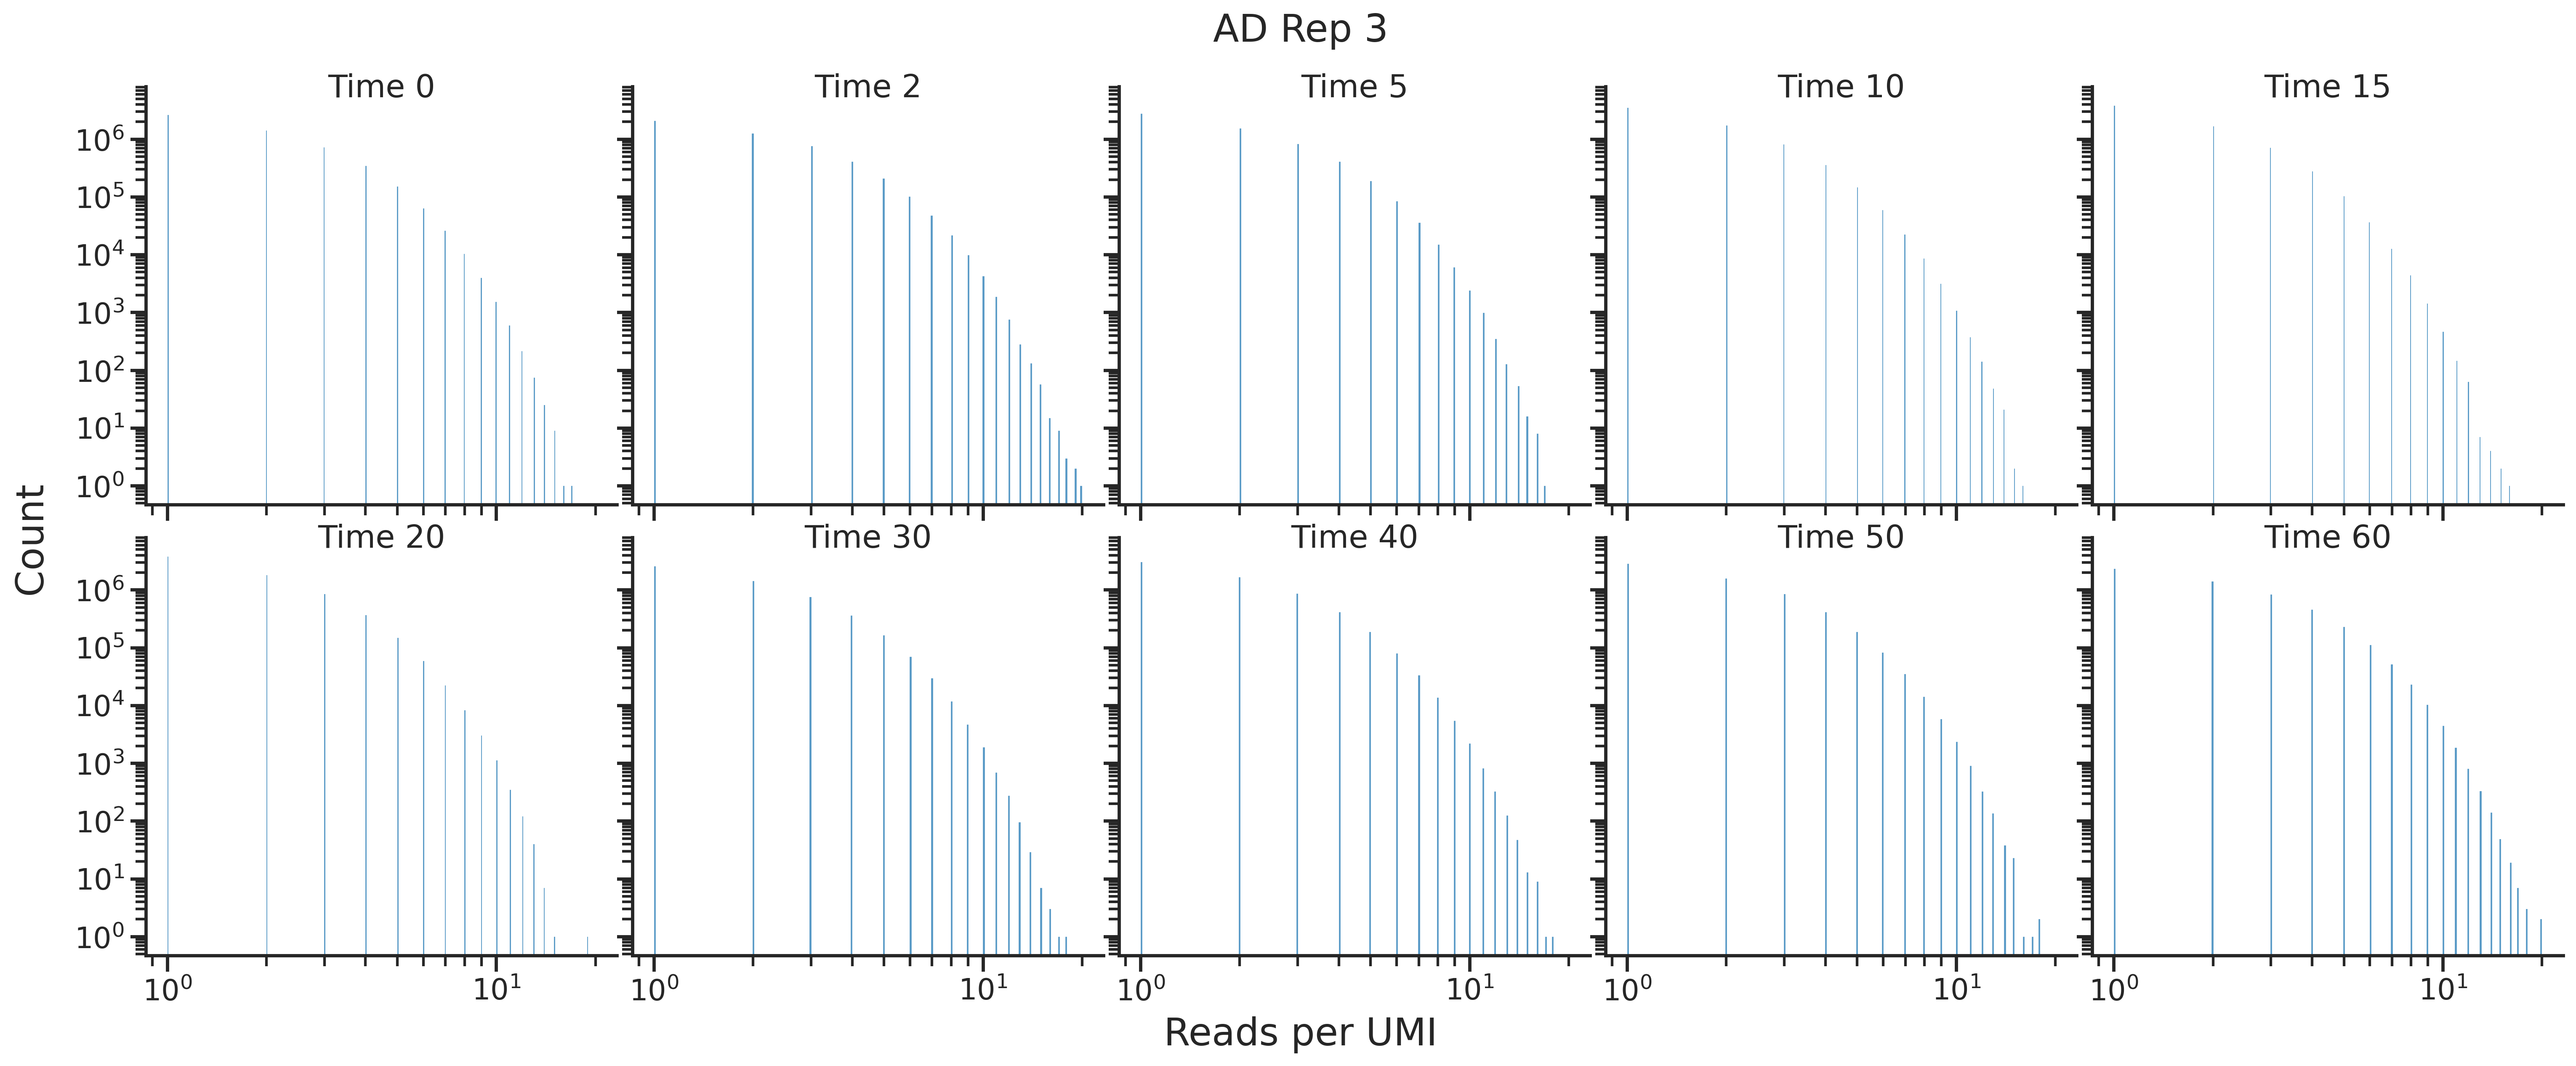

../../../output/ChopTFs_pipeline/trebl_experiment_/trebl_experiment_AD_4_0_S21_R1_001_fastp/AD_4_0_S21_R1_001_fastp_reads_per_umi.tsv
../../../output/ChopTFs_pipeline/trebl_experiment_/trebl_experiment_AD_4_2_S22_R1_001_fastp/AD_4_2_S22_R1_001_fastp_reads_per_umi.tsv
../../../output/ChopTFs_pipeline/trebl_experiment_/trebl_experiment_AD_4_5_S23_R1_001_fastp/AD_4_5_S23_R1_001_fastp_reads_per_umi.tsv
../../../output/ChopTFs_pipeline/trebl_experiment_/trebl_experiment_AD_4_10_S24_R1_001_fastp/AD_4_10_S24_R1_001_fastp_reads_per_umi.tsv
../../../output/ChopTFs_pipeline/trebl_experiment_/trebl_experiment_AD_4_15_S25_R1_001_fastp/AD_4_15_S25_R1_001_fastp_reads_per_umi.tsv
../../../output/ChopTFs_pipeline/trebl_experiment_/trebl_experiment_AD_4_20_S26_R1_001_fastp/AD_4_20_S26_R1_001_fastp_reads_per_umi.tsv
../../../output/ChopTFs_pipeline/trebl_experiment_/trebl_experiment_AD_4_30_S27_R1_001_fastp/AD_4_30_S27_R1_001_fastp_reads_per_umi.tsv
../../../output/ChopTFs_pipeline/trebl_experiment_/tre

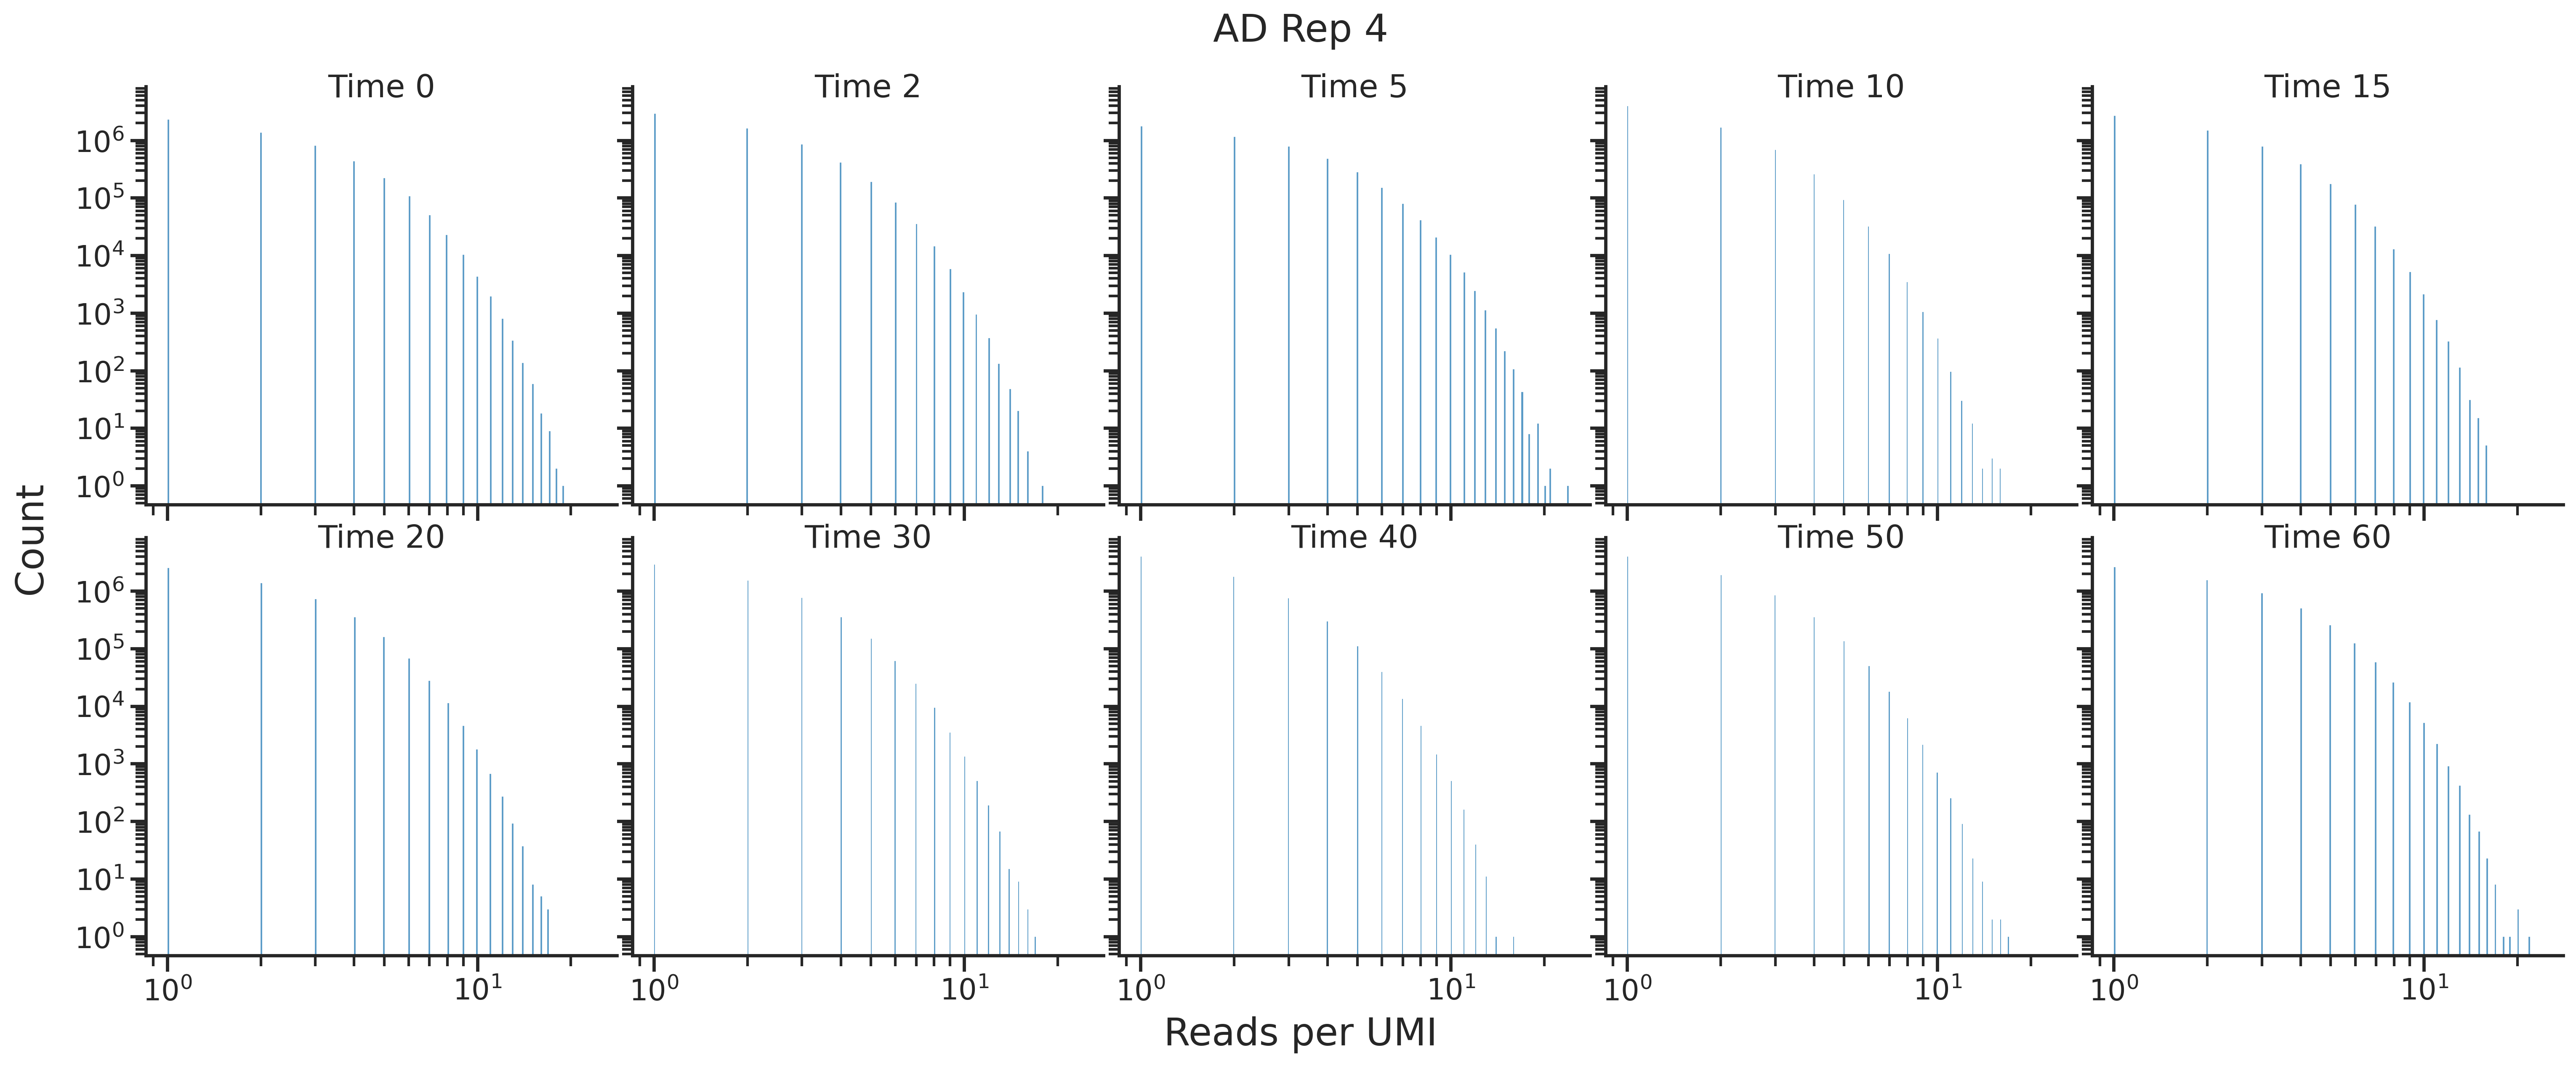

../../../output/ChopTFs_pipeline/trebl_experiment_/trebl_experiment_RP_2_0_S31_R1_001_fastp/RP_2_0_S31_R1_001_fastp_reads_per_umi.tsv
../../../output/ChopTFs_pipeline/trebl_experiment_/trebl_experiment_RP_2_2_S32_R1_001_fastp/RP_2_2_S32_R1_001_fastp_reads_per_umi.tsv
../../../output/ChopTFs_pipeline/trebl_experiment_/trebl_experiment_RP_2_5_S33_R1_001_fastp/RP_2_5_S33_R1_001_fastp_reads_per_umi.tsv
../../../output/ChopTFs_pipeline/trebl_experiment_/trebl_experiment_RP_2_10_S34_R1_001_fastp/RP_2_10_S34_R1_001_fastp_reads_per_umi.tsv
../../../output/ChopTFs_pipeline/trebl_experiment_/trebl_experiment_RP_2_15_S35_R1_001_fastp/RP_2_15_S35_R1_001_fastp_reads_per_umi.tsv
../../../output/ChopTFs_pipeline/trebl_experiment_/trebl_experiment_RP_2_20_S36_R1_001_fastp/RP_2_20_S36_R1_001_fastp_reads_per_umi.tsv
../../../output/ChopTFs_pipeline/trebl_experiment_/trebl_experiment_RP_2_30_S37_R1_001_fastp/RP_2_30_S37_R1_001_fastp_reads_per_umi.tsv
../../../output/ChopTFs_pipeline/trebl_experiment_/tre

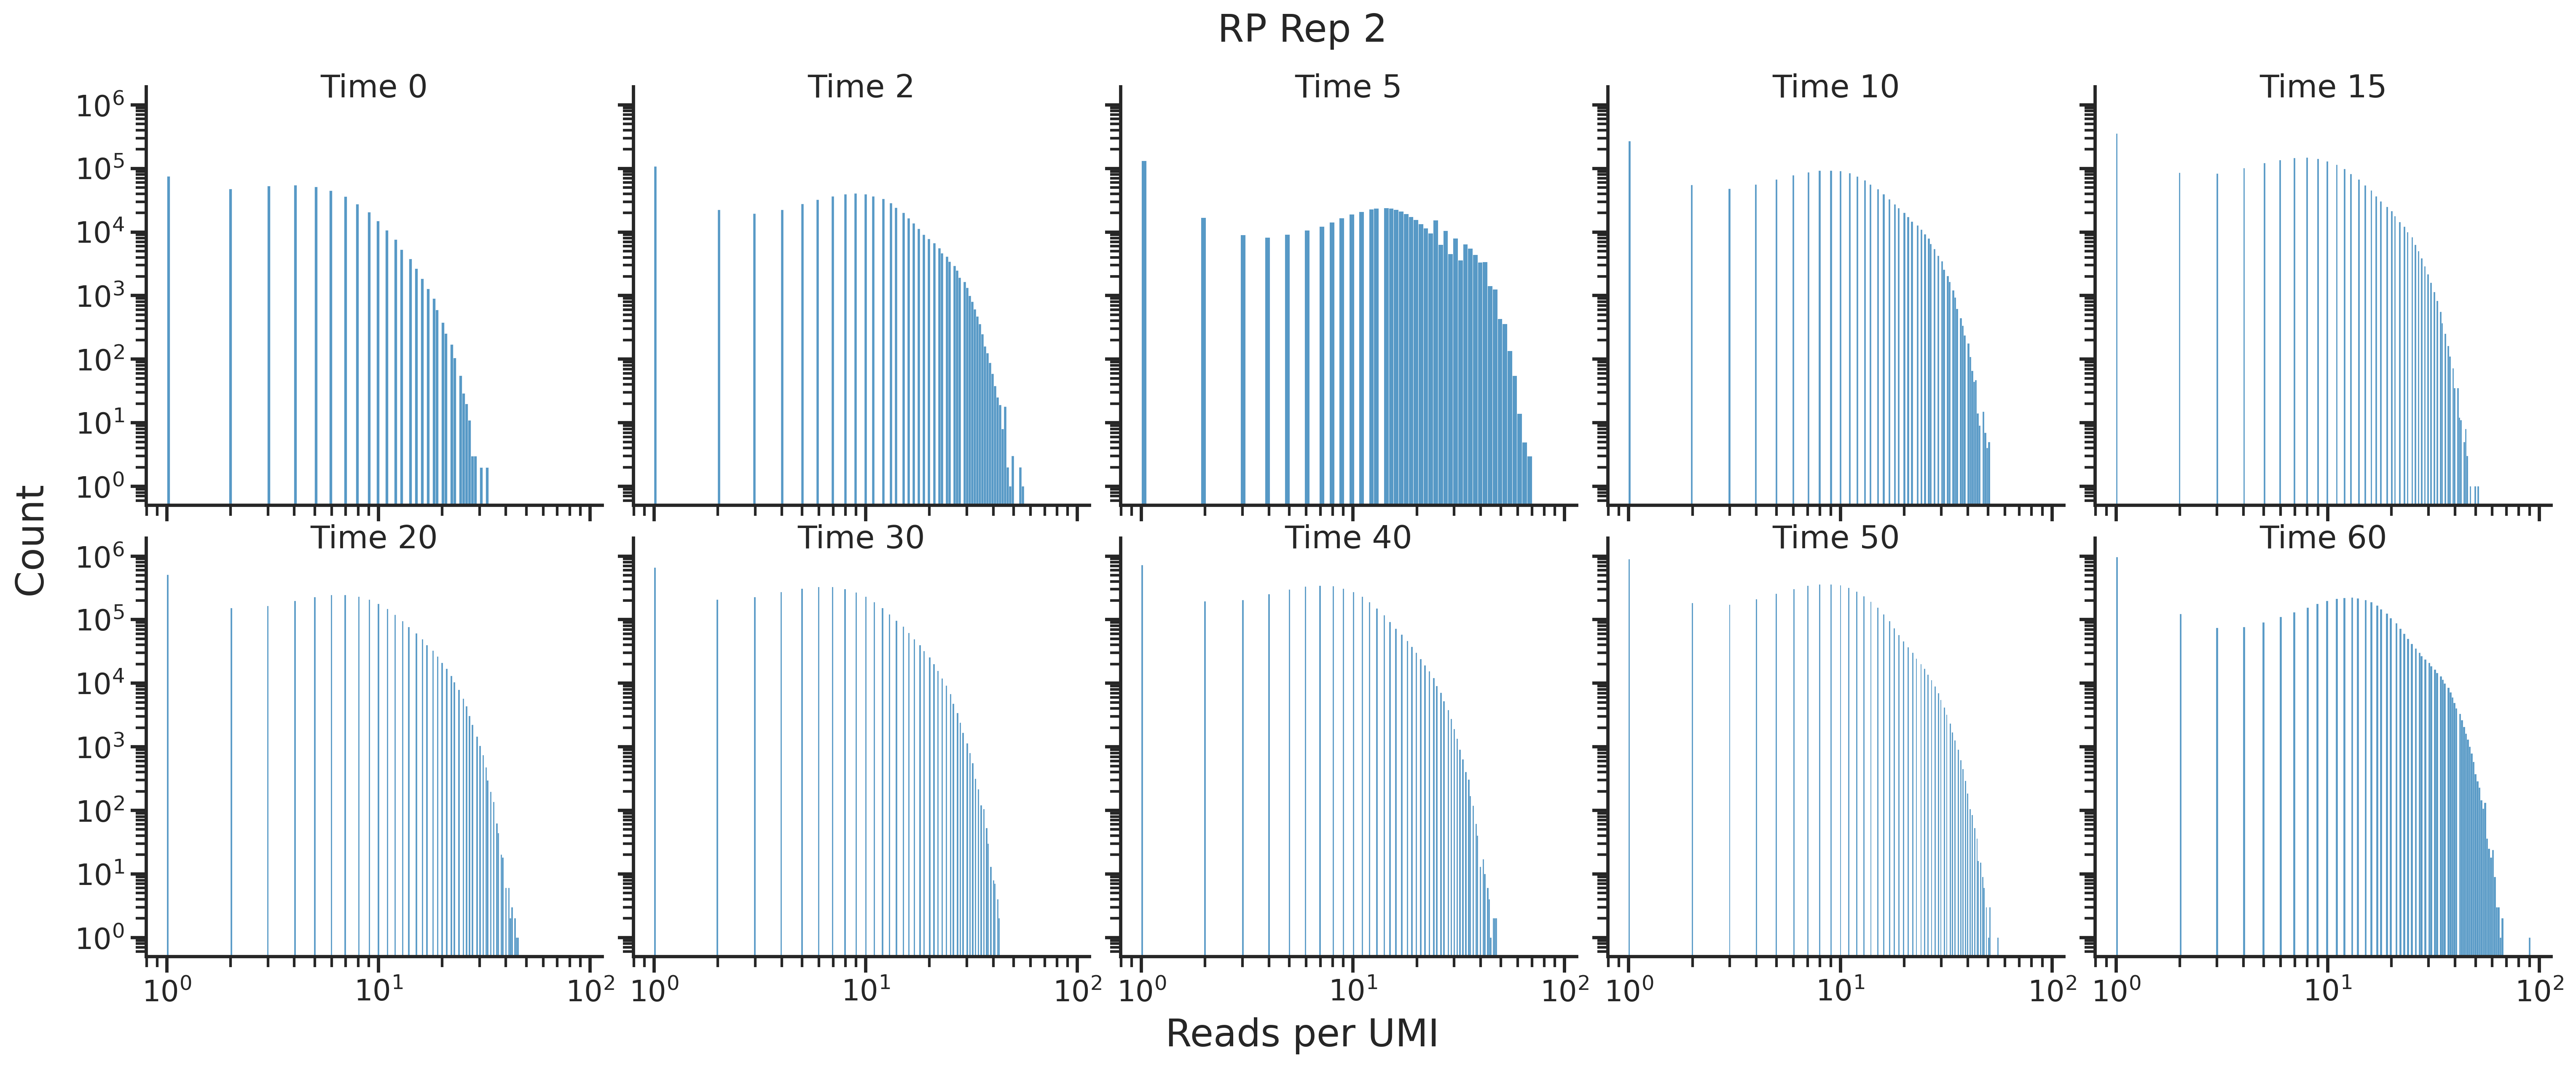

../../../output/ChopTFs_pipeline/trebl_experiment_/trebl_experiment_RP_3_0_S41_R1_001_fastp/RP_3_0_S41_R1_001_fastp_reads_per_umi.tsv
../../../output/ChopTFs_pipeline/trebl_experiment_/trebl_experiment_RP_3_2_S42_R1_001_fastp/RP_3_2_S42_R1_001_fastp_reads_per_umi.tsv
../../../output/ChopTFs_pipeline/trebl_experiment_/trebl_experiment_RP_3_5_S43_R1_001_fastp/RP_3_5_S43_R1_001_fastp_reads_per_umi.tsv
../../../output/ChopTFs_pipeline/trebl_experiment_/trebl_experiment_RP_3_10_S44_R1_001_fastp/RP_3_10_S44_R1_001_fastp_reads_per_umi.tsv
../../../output/ChopTFs_pipeline/trebl_experiment_/trebl_experiment_RP_3_15_S45_R1_001_fastp/RP_3_15_S45_R1_001_fastp_reads_per_umi.tsv
../../../output/ChopTFs_pipeline/trebl_experiment_/trebl_experiment_RP_3_20_S46_R1_001_fastp/RP_3_20_S46_R1_001_fastp_reads_per_umi.tsv
../../../output/ChopTFs_pipeline/trebl_experiment_/trebl_experiment_RP_3_30_S47_R1_001_fastp/RP_3_30_S47_R1_001_fastp_reads_per_umi.tsv
../../../output/ChopTFs_pipeline/trebl_experiment_/tre

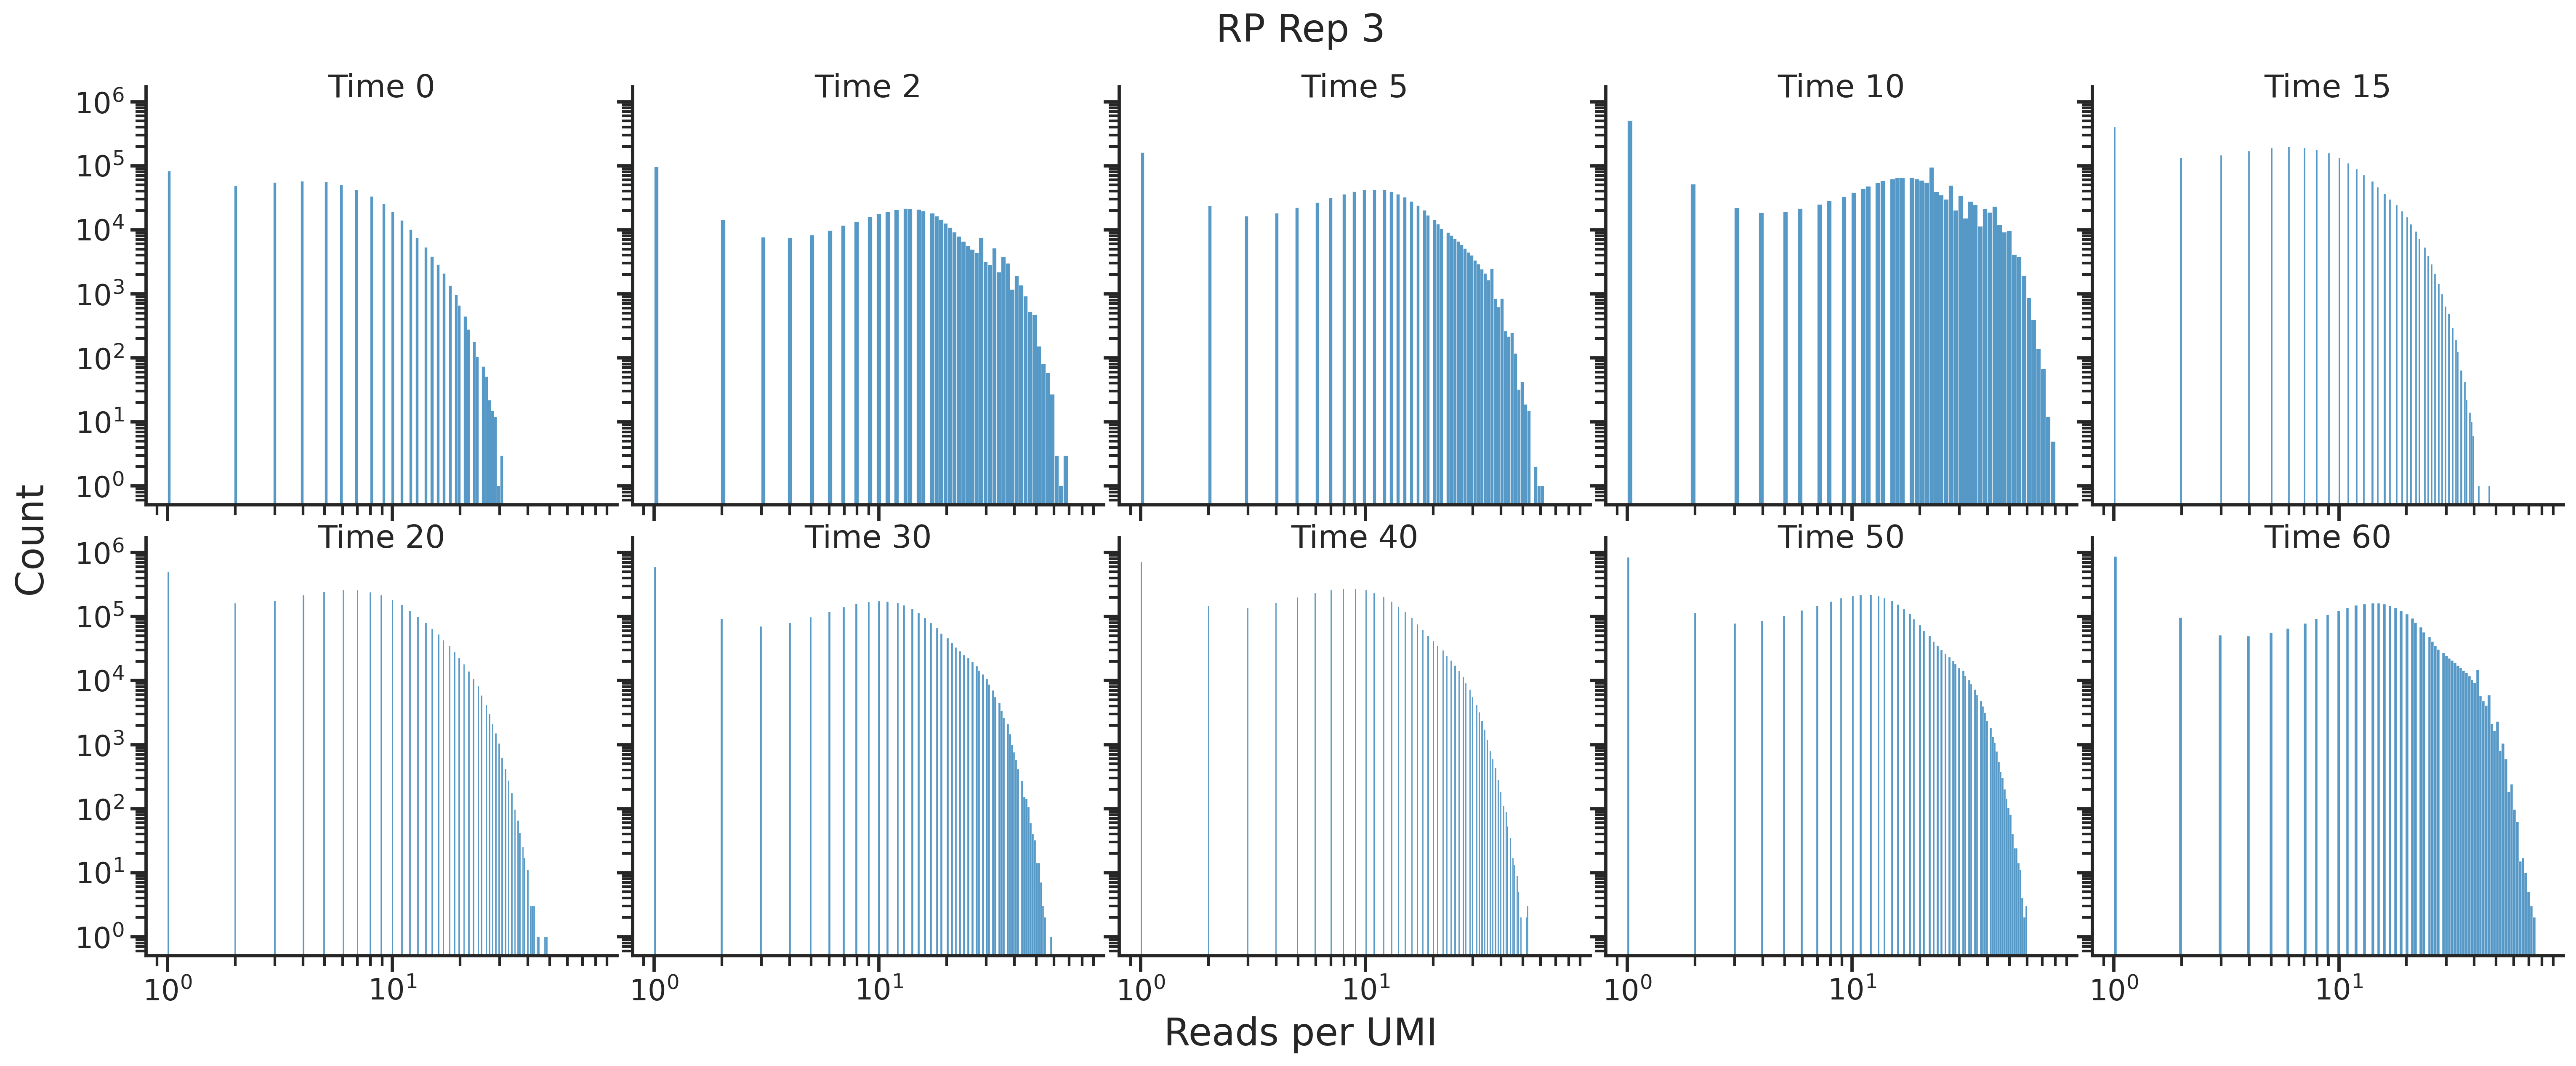

../../../output/ChopTFs_pipeline/trebl_experiment_/trebl_experiment_RP_4_0_S51_R1_001_fastp/RP_4_0_S51_R1_001_fastp_reads_per_umi.tsv
../../../output/ChopTFs_pipeline/trebl_experiment_/trebl_experiment_RP_4_2_S52_R1_001_fastp/RP_4_2_S52_R1_001_fastp_reads_per_umi.tsv
../../../output/ChopTFs_pipeline/trebl_experiment_/trebl_experiment_RP_4_5_S53_R1_001_fastp/RP_4_5_S53_R1_001_fastp_reads_per_umi.tsv
../../../output/ChopTFs_pipeline/trebl_experiment_/trebl_experiment_RP_4_10_S54_R1_001_fastp/RP_4_10_S54_R1_001_fastp_reads_per_umi.tsv
../../../output/ChopTFs_pipeline/trebl_experiment_/trebl_experiment_RP_4_15_S55_R1_001_fastp/RP_4_15_S55_R1_001_fastp_reads_per_umi.tsv
../../../output/ChopTFs_pipeline/trebl_experiment_/trebl_experiment_RP_4_20_S56_R1_001_fastp/RP_4_20_S56_R1_001_fastp_reads_per_umi.tsv
../../../output/ChopTFs_pipeline/trebl_experiment_/trebl_experiment_RP_4_30_S57_R1_001_fastp/RP_4_30_S57_R1_001_fastp_reads_per_umi.tsv
../../../output/ChopTFs_pipeline/trebl_experiment_/tre

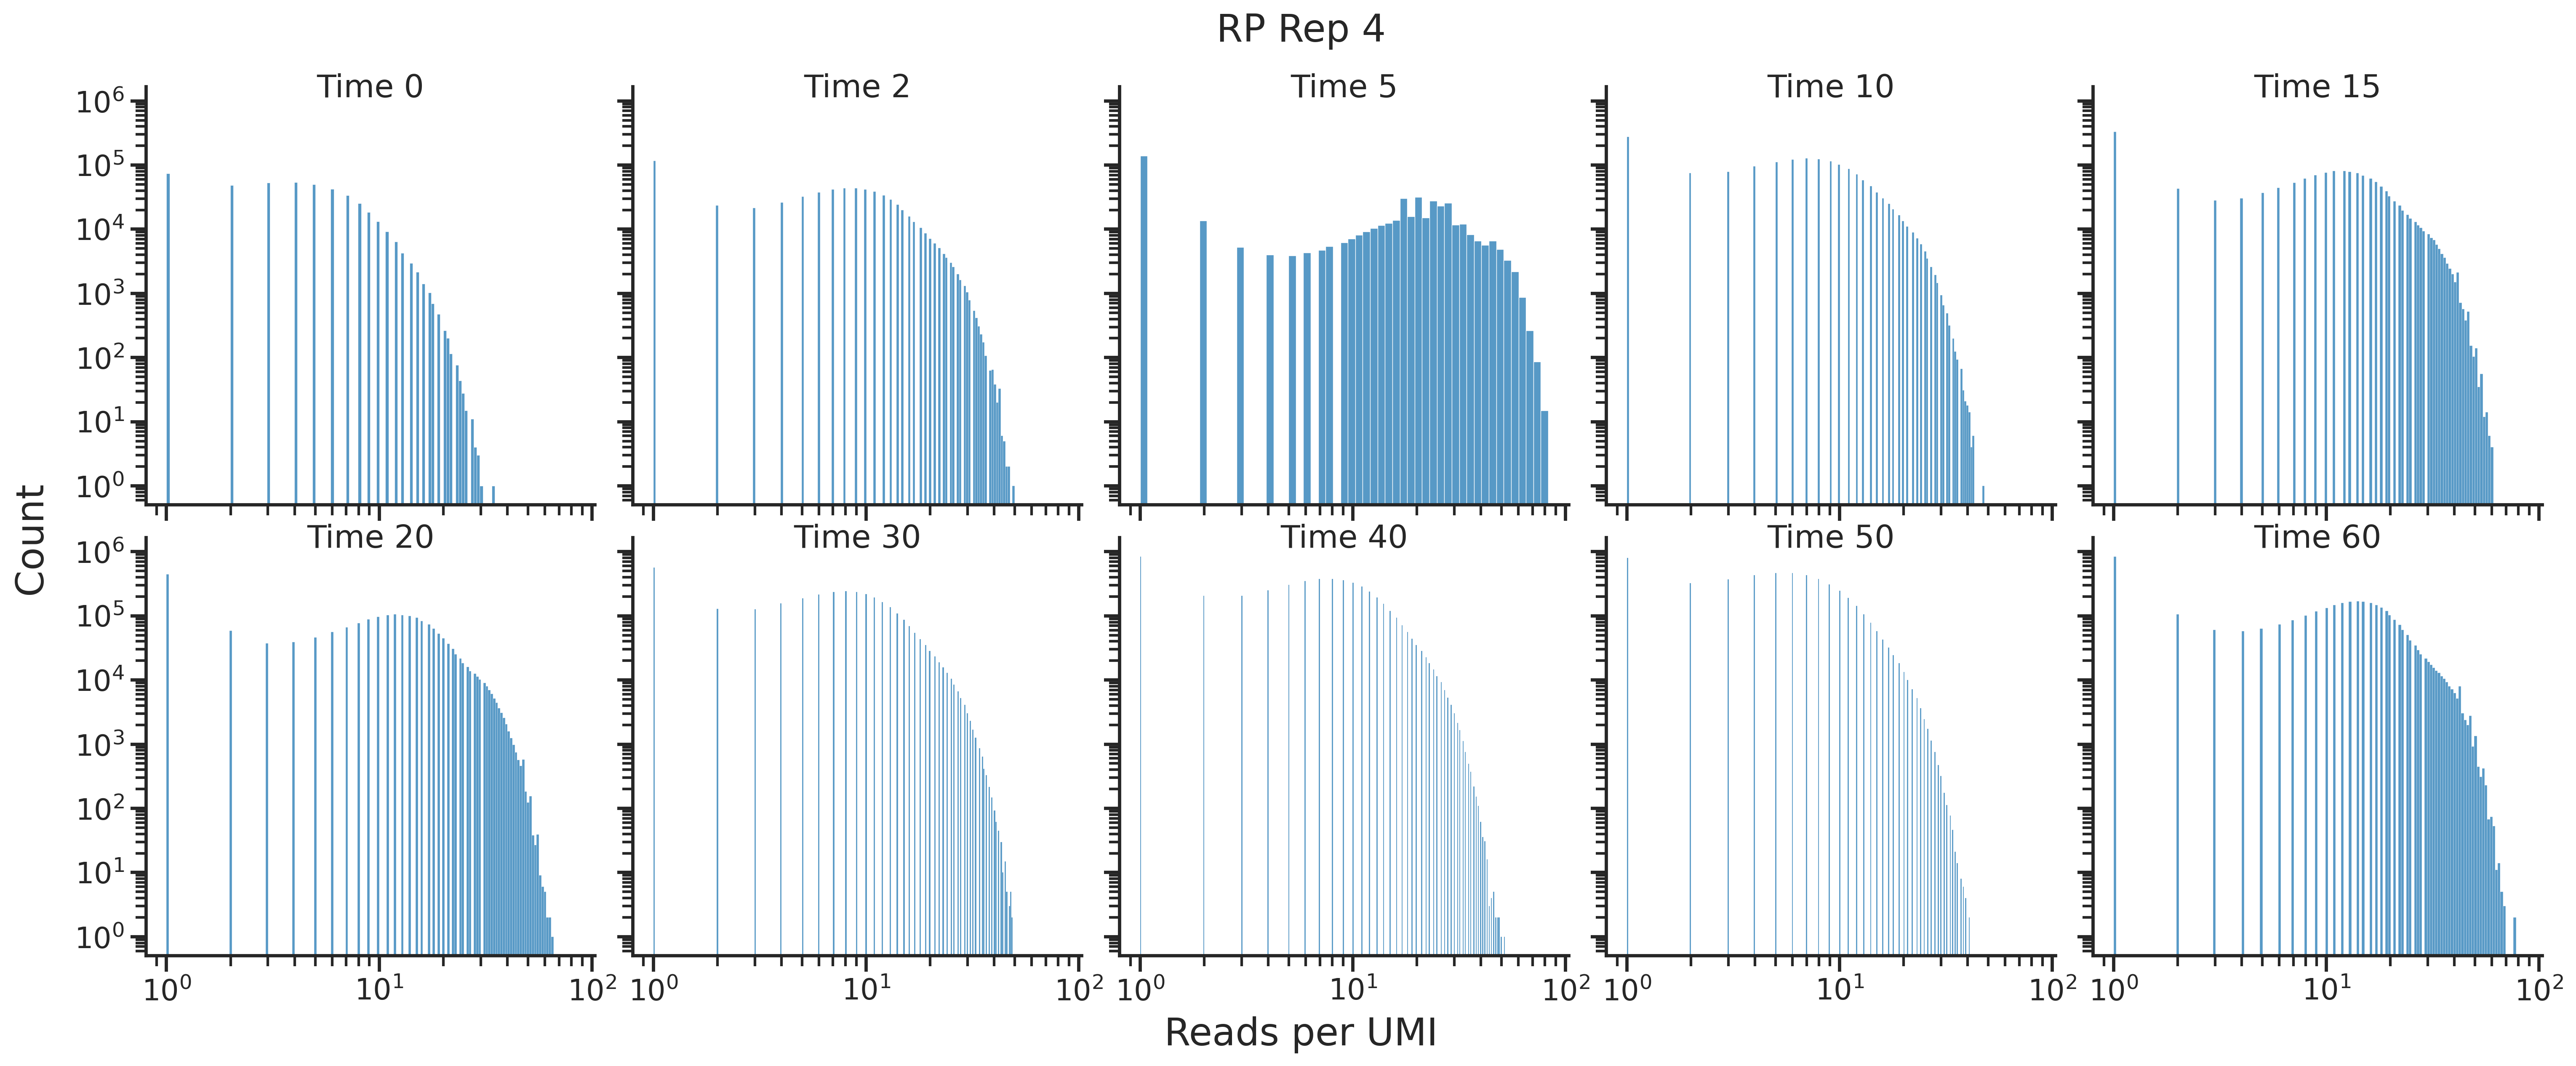

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_context("talk")
sns.set_style("ticks")

# Assuming your dataframe is called df_paths
# Columns: path (0), seq_type, rep, time
df_paths = reads_per_umi_paths_df

# Group by seq_type and rep
for (seq_type, rep), group in df_paths.groupby(["seq_type", "rep"]):
    n_files = len(group)
    n_cols = 5  # adjust depending on layout
    n_rows = (n_files + n_cols - 1) // n_cols  # ceil division

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 4*n_rows), sharex = True, sharey = True, dpi = 300)
    axes = axes.flatten()  # flatten in case of single row/col

    for i, (_, row) in enumerate(group.iterrows()):
        print(row["path"])
        reads_df = pd.read_csv(row["path"], sep="\t")
        sns.histplot(
            reads_df["reads"],
            log_scale=(True, True), 
            ax=axes[i], 
            kde=False
        )
        axes[i].set_title(f"Time {row['time']}", y =0.95)
        axes[i].set_xlabel("Reads per UMI")
        axes[i].set_ylabel("Count")
        axes[i].set_xlabel("")
        axes[i].set_ylabel("")

    # Remove unused subplots
    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])

    sns.despine()

    plt.suptitle(f"{seq_type} Rep {rep}", y = 1.02)
    fig.supxlabel("Reads per UMI", y = -0.01)
    fig.supylabel("Count", x = -0.01)
    
    plt.tight_layout(pad = 0)
    plt.show()

In [ ]:
for path in reads_per_umi_paths_df[0]:
    

In [5]:
reads_per_umi = pd.read_csv(reads_per_umi_paths[0], sep = "\t")
reads_per_umi

,AD_end,AD_BC,UMI,reads,name
0,AAAAAAAAAAACTACTGTCTTGCAACCAGCTTCTCATTCT,CCCCCCGAGTT,CTCGCAGCCACC,1,AD_4_50_S29_R1_001_fastp
1,AAAAAAAAAAACTACTGTCTTGCAACCAGCTTCTCATTCT,CGAGACTTTTT,GACCGGGCCAGG,1,AD_4_50_S29_R1_001_fastp
2,AAAAAAAAAACAAAAAAAACAACAACAACAACAACCACAA,AACCCCCCAGT,CCCCCCCCAAAT,1,AD_4_50_S29_R1_001_fastp
3,AAAAAAAAAAGCTACTGTCTTGCAACCAGCTTCTCATTCT,CCCCCCGAGTT,GATTTTCCACCA,1,AD_4_50_S29_R1_001_fastp
4,AAAAAAAAAAGCTACTGTCTTGCAACCAGCTTCTCATTCT,CCCCCCGAGTT,GCCCTCAGCCCC,1,AD_4_50_S29_R1_001_fastp
...,...,...,...,...,...
7294598,TTTTTTTTCTTCTTCTTCTTCTTCTTCTTCTTCTTCTTCT,TCCGCTGTCTA,AGCCCCGTCAGG,1,AD_4_50_S29_R1_001_fastp
7294599,TTTTTTTTTTATTTTCTTGTGTTTGTTTGGGGGTATGGGT,GACGACCCTGG,TTAGCATACTAG,1,AD_4_50_S29_R1_001_fastp
7294600,TTTTTTTTTTGTTTTGGAAGGTTTGTGGGAGGAAAGGGGT,CCGTGCGCGCA,ACCTCCCAACCC,1,AD_4_50_S29_R1_001_fastp
7294601,TTTTTTTTTTGTTTTGGAGGGTTTGTGGGGGGAAGGGGGT,CTGTGCGCGCA,AGCGCCCACAAC,1,AD_4_50_S29_R1_001_fastp
